# Customer Churn Prediction — Multi-Algorithm Classification Showdown

## Step 1: Problem Framing & Theory Notes

### Q1. What is Customer Churn? Why is predicting churn valuable for a business like Jio or Airtel?

**Customer Churn** means a paying subscriber stops using the company's service and either switches to a competitor or cancels entirely.

**Why predicting it is valuable:**

- **CAC (Customer Acquisition Cost):** What the company spends to bring a new customer in through advertising, offers and onboarding. Research consistently shows CAC is 5–10x higher than the cost of keeping an existing customer.
- **CLV (Customer Lifetime Value):** The total revenue a customer generates over their relationship with the company. When a customer churns, that entire remaining CLV is lost.
- A churn model lets the retention team step in before a customer leaves — a timely call or discount offer is far cheaper than replacing a lost subscriber from scratch.

### Q2. Confusion Matrix — Four Cells and Business Cost in Churn Context

| | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn** | **TN** — correctly left alone | **FP** — wasted retention offer |
| **Actual: Churn** | **FN** — customer leaves undetected | **TP** — team reaches out in time |

- **TP (True Positive):** Predicted Churn and customer actually churned → retention team contacts them in time. Best outcome.
- **TN (True Negative):** Predicted No Churn and customer stayed → no intervention needed. Correct.
- **FP (False Positive):** Predicted Churn but customer was not going to leave → a retention offer is wasted on a loyal customer. Small fixed cost.
- **FN (False Negative):** Predicted No Churn but customer actually churned → team never calls, customer leaves undetected. **Most costly mistake** — the company loses the full remaining CLV plus must spend CAC to replace them.

### Q3. What is Class Imbalance? Does the Telco Dataset Have It? How Does SMOTE Address It?

**Class Imbalance** means one class in the target variable has far more samples than the other. In most churn datasets, the majority of customers stay, so Non-Churn heavily outnumbers Churn.

**In the Telco dataset:** approximately 26.5% of customers churned and 73.5% did not — a roughly 3:1 imbalance. A model trained without handling this could achieve ~73.5% accuracy just by always predicting No Churn, while completely missing every actual churner.

**How SMOTE addresses it:**
- SMOTE (Synthetic Minority Over-sampling Technique) finds existing minority class (Churn) samples, locates their nearest neighbours in feature space, and generates new synthetic churn records placed between them.
- This brings the training class counts to a 1:1 balance, giving the model equal exposure to both classes during training.
- **Important rule:** SMOTE is applied only to the training data, never the test set. The test set must stay original to give an honest, real-world evaluation.

### Q4. The Four Algorithms — Brief Explanation

- **KNN (K-Nearest Neighbors):** Distance-based classifier. When classifying a new customer, it finds the 'k' most similar customers in training data and votes on the majority class. No real training step — all computation happens at prediction time. Feature scaling is essential since it works purely on distances.
- **Naive Bayes (Gaussian NB):** Probabilistic classifier using Bayes' Theorem. Assumes all features are independent given the class label. Very fast, gives probability scores directly. Works surprisingly well even when the independence assumption is violated.
- **SVM (Support Vector Machine):** Margin-based classifier. Finds the hyperplane that separates churners from non-churners with the largest possible gap (margin). RBF kernel allows flexible, curved boundaries. Strong performance but acts as a black box — you can't easily see why it made a prediction.
- **Decision Tree:** Rule-based classifier. Learns a tree of if-then decisions by splitting data on the feature that best separates the classes at each step. Fully interpretable — the tree structure and feature importances are readable by both data scientists and business teams.

### Q5. When Would You Choose Precision Over Recall? Churn-Specific Answer

- **Recall** (prioritize catching all real churners) vs **Precision** (prioritize only flagging actual churners)

**For churn prediction, Recall is the primary metric** because:
- A **False Negative** (missing a real churner) costs the company that customer's full remaining CLV plus CAC to find a replacement. This loss is large and permanent.
- A **False Positive** (flagging someone who wasn't going to leave) costs only one unnecessary retention call or discount offer — a small, fixed expense.

**When you'd choose Precision instead:** If the retention offer is very expensive (a free 3-month subscription) and the team's budget is limited, sending offers to too many non-churners would waste money fast. In that case, Precision matters more to ensure only genuinely at-risk customers receive the expensive intervention.

## Step 2: EDA

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

### 2.1 Load & Inspect

#### Load Dataset

In [2]:
df = pd.read_csv("../Dataset/Telco-Customer-Churn.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#### Observation

The dataset has been loaded. Each row is one customer. Columns cover demographics, subscribed services, contract details, billing, and whether they churned.

#### Shape

In [3]:
print(df.shape)

(7043, 21)


#### Observation

7043 customers and 21 columns. A compact but real-world dataset — the challenge here is model selection and correct handling of imbalance, not data size.

#### Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Observation

Most columns are object (string) type. MonthlyCharges is already float64. TotalCharges loaded as object even though it should be numeric — this needs to be fixed. SeniorCitizen is already int (0 or 1).

#### Describe

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Observation

tenure ranges 0–72 months. MonthlyCharges goes from about 18 to 119. TotalCharges doesn't show up here because it's still stored as an object column — another reason we need to convert it.

#### Fix TotalCharges Column

TotalCharges has whitespace strings for customers with tenure = 0 (brand new customers who haven't been billed yet). These become NaN when we convert to float.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges null values after conversion:", df['TotalCharges'].isnull().sum())
print()
print("All null rows have tenure = 0:")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

TotalCharges null values after conversion: 11

All null rows have tenure = 0:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


#### Observation

11 rows had whitespace in TotalCharges — every single one has tenure = 0, confirming these are genuinely new customers with no billing history. They will be filled with the median TotalCharges during preprocessing.

#### Class Balance Check

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(f"No Churn : {churn_pct['No']:.2f}%")
print(f"Churn    : {churn_pct['Yes']:.2f}%")
print()
print("This dataset is IMBALANCED — churners are a minority class (~26.5%).")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

No Churn : 73.46%
Churn    : 26.54%

This dataset is IMBALANCED — churners are a minority class (~26.5%).


#### Observation

26.5% of customers churned. A model that always predicts No Churn would still score ~73.5% accuracy while being completely useless. This confirms we must handle the imbalance before training — which is exactly what SMOTE is for.

### 2.2 Univariate Analysis

All EDA is done on a copy of the original dataframe so the raw data stays untouched.

In [8]:
df_eda = df.copy()

#### Countplot of Target Variable: Churn

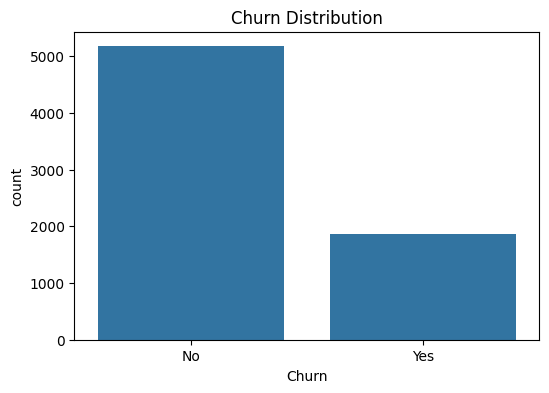

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_eda)
plt.title("Churn Distribution")
plt.show()

#### Observation

The height difference between No and Yes clearly shows the class imbalance. The No Churn bar is roughly 3x taller than the Churn bar.

#### Histograms: tenure, MonthlyCharges, TotalCharges

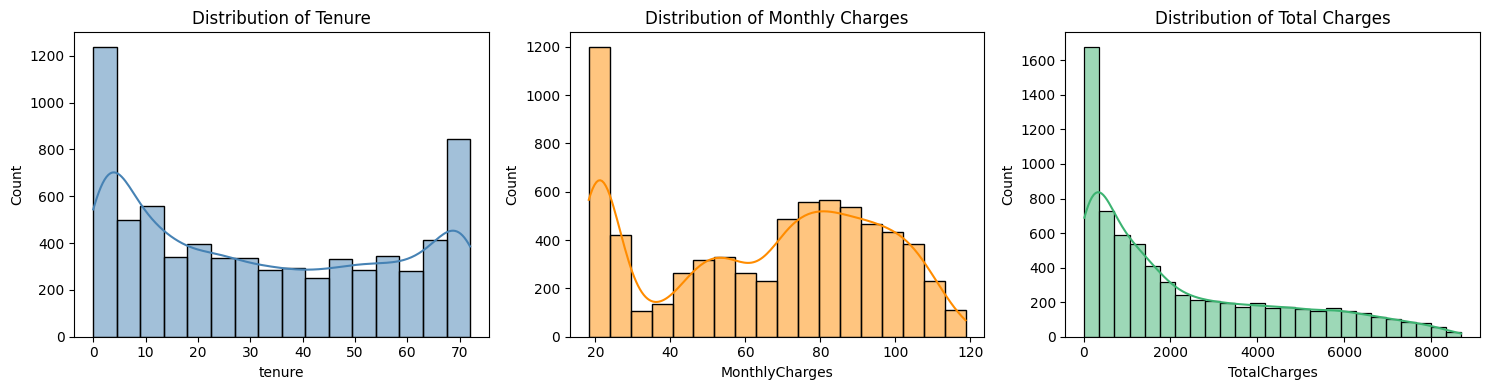

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(df_eda['tenure'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Tenure')

sns.histplot(df_eda['MonthlyCharges'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Monthly Charges')

sns.histplot(df_eda['TotalCharges'].dropna(), kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribution of Total Charges')

plt.tight_layout()
plt.show()

#### Observation

Tenure is bimodal — many new customers and many long-standing ones, suggesting two groups: new joiners who churn quickly and loyal customers who stick around for years. MonthlyCharges is spread fairly evenly with a slight right skew. TotalCharges is right-skewed since it accumulates with tenure.

#### Countplots: Contract, InternetService, PaymentMethod

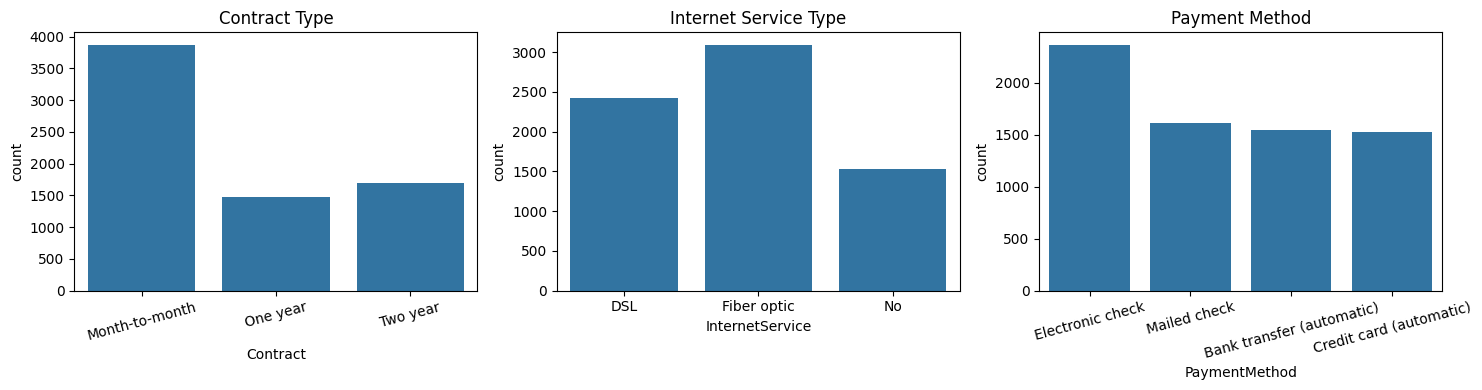

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(x='Contract', data=df_eda, ax=axes[0])
axes[0].set_title('Contract Type')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(x='InternetService', data=df_eda, ax=axes[1])
axes[1].set_title('Internet Service Type')

sns.countplot(x='PaymentMethod', data=df_eda, ax=axes[2])
axes[2].set_title('Payment Method')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#### Observation

Most customers are on Month-to-Month contracts — the most flexible and likely the most churn-prone. Fiber optic is popular but also the priciest tier. Electronic check is the most common payment method among all customers.

### 2.3 Bivariate Analysis

#### Churn Rate by Contract Type

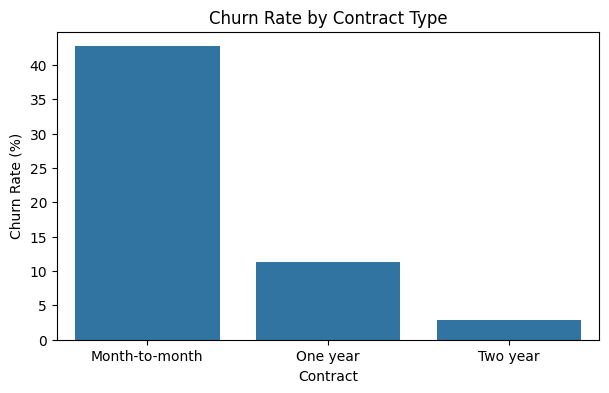

         Contract  Churn Rate (%)
0  Month-to-month       42.709677
1        One year       11.269518
2        Two year        2.831858


In [12]:
churn_by_contract = (df_eda.groupby('Contract')['Churn']
                     .apply(lambda x: (x == 'Yes').mean() * 100)
                     .reset_index())
churn_by_contract.columns = ['Contract', 'Churn Rate (%)']

plt.figure(figsize=(7,4))
sns.barplot(x='Contract', y='Churn Rate (%)', data=churn_by_contract)
plt.title("Churn Rate by Contract Type")
plt.show()

print(churn_by_contract)

#### Observation

Month-to-Month customers churn at a dramatically higher rate compared to customers on One Year or Two Year contracts. This is one of the strongest churn signals in the entire dataset — longer contracts create switching friction that significantly reduces churn risk.

#### Churn Rate by Tenure Bucket (0–12, 13–24, 25–48, 49–72 months)

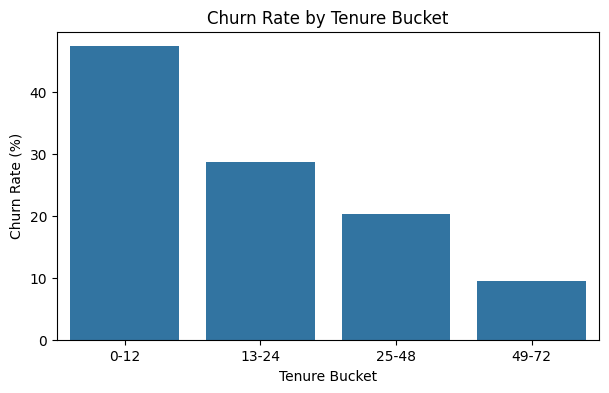

  Tenure Bucket  Churn Rate (%)
0          0-12       47.438243
1         13-24       28.710938
2         25-48       20.388959
3         49-72        9.513176


In [13]:
df_eda['tenure_bucket'] = pd.cut(df_eda['tenure'],
                                 bins=[0, 12, 24, 48, 72],
                                 labels=['0-12', '13-24', '25-48', '49-72'],
                                 include_lowest=True)

churn_by_tenure = (df_eda.groupby('tenure_bucket', observed=True)['Churn']
                   .apply(lambda x: (x == 'Yes').mean() * 100)
                   .reset_index())
churn_by_tenure.columns = ['Tenure Bucket', 'Churn Rate (%)']

plt.figure(figsize=(7,4))
sns.barplot(x='Tenure Bucket', y='Churn Rate (%)', data=churn_by_tenure)
plt.title("Churn Rate by Tenure Bucket")
plt.show()

print(churn_by_tenure)

#### Observation

New customers (0–12 months) have the highest churn rate, above 40%. It drops sharply as tenure increases. Customers in the 49–72 month group have around 10% churn. The first year is the critical window — if a customer survives it, they are far more likely to stay long-term.

#### Boxplot: MonthlyCharges vs Churn

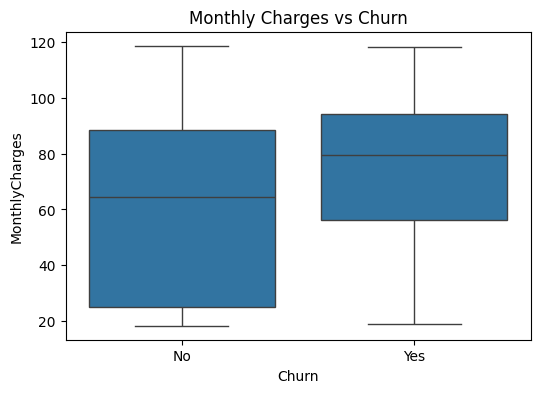

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_eda)
plt.title("Monthly Charges vs Churn")
plt.show()

#### Observation

Churners clearly pay more per month on average compared to retained customers. The median MonthlyCharges for churners is noticeably higher, suggesting that customers on expensive plans feel the price isn't worth it and are more likely to switch.

#### Correlation Heatmap (Numerical Features)

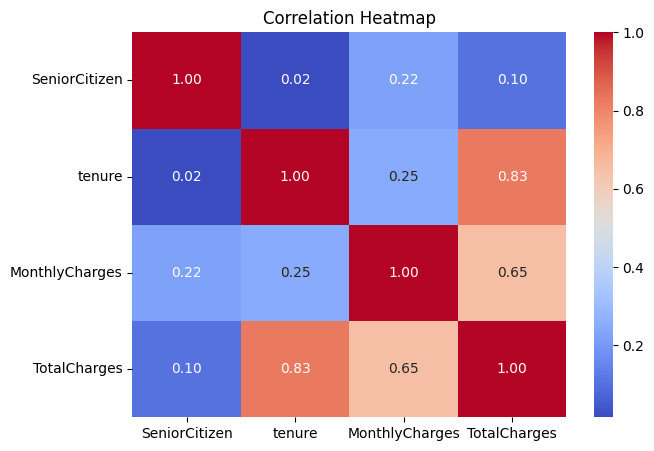

In [15]:
plt.figure(figsize=(7,5))
num_cols = df_eda.select_dtypes(include='number').columns.tolist()
corr = df_eda[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Observation

tenure and TotalCharges are strongly correlated (0.83) since TotalCharges builds up over time. MonthlyCharges and TotalCharges also correlate moderately. No single numeric feature has an overwhelming direct correlation with SeniorCitizen, which is why we need proper classifiers rather than simple threshold rules.

## Step 3: Data Preprocessing & Feature Engineering

A fresh copy is used for all preprocessing so the original df stays untouched.

In [16]:
df_model = df.copy()

### 3.1 Drop & Clean

In [17]:
df_model = df_model.drop(columns=['customerID'])

df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(df_model['TotalCharges'].median())

print("Remaining null values:", df_model.isnull().sum().sum())

Remaining null values: 0


#### Observation

customerID is dropped — it's just a row identifier with no predictive value. The 11 whitespace TotalCharges values are filled with the column median, which is more robust than the mean for a right-skewed column like this one.

### 3.2 Feature Engineering

In [18]:
# tenure_group: lifecycle stage of the customer
df_model['tenure_group'] = pd.cut(df_model['tenure'],
                                   bins=[0, 12, 36, 60, 100],
                                   labels=['New', 'Mid', 'Senior', 'Loyal'],
                                   include_lowest=True)

# num_services: total add-on services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df_model['num_services'] = df_model[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# AutoPay: 1 if payment method is automatic, 0 otherwise
df_model['AutoPay'] = df_model['PaymentMethod'].str.contains('automatic', case=False).astype(int)

print(df_model[['tenure', 'tenure_group', 'num_services', 'AutoPay']].head(8))

   tenure tenure_group  num_services  AutoPay
0       1          New             1        0
1      34          Mid             2        0
2       2          New             2        0
3      45       Senior             3        1
4       2          New             0        0
5       8          New             3        0
6      22          Mid             2        1
7      10          New             1        0


#### Observation

tenure_group bins customers into four lifecycle stages which are more business-meaningful than raw months. num_services counts how many add-on features a customer uses — highly embedded customers (many services) tend to have higher switching costs and lower churn risk. AutoPay flags automatic payment customers who don't actively choose to pay each month and tend to churn less.

### 3.3 Encoding

**Binary Columns — map Yes/No to 1/0**

For service columns that can have 'No internet service' or 'No phone service', these are treated as 0 (same as No).

In [19]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df_model[col] = df_model[col].map(lambda x: 1 if x == 'Yes' else 0)

df_model['gender'] = df_model['gender'].map({'Female': 1, 'Male': 0})

print(df_model[['gender', 'Partner', 'Churn']].head())

   gender  Partner  Churn
0       1        1      0
1       0        0      0
2       0        0      1
3       0        0      0
4       1        0      1


#### Observation

All binary columns now contain only 0 or 1. Service columns with 'No internet service' or 'No phone service' are treated as 0 since the customer effectively doesn't have that service. gender is mapped Female=1, Male=0.

**One-Hot Encoding — InternetService, Contract, PaymentMethod**

In [20]:
df_model = pd.get_dummies(df_model, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
print("Shape after encoding:", df_model.shape)
df_model.head(2)

Shape after encoding: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,New,1,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,Mid,2,0,False,False,True,False,False,False,True


#### Observation

One-Hot Encoding turns each multi-class column into multiple binary columns. drop_first=True removes one column per feature to avoid the dummy variable trap (perfect multicollinearity).

**Label Encoding — tenure_group (preserving ordinal order)**

In [21]:
tenure_order = {'New': 0, 'Mid': 1, 'Senior': 2, 'Loyal': 3}
df_model['tenure_group'] = df_model['tenure_group'].map(tenure_order)

print(df_model['tenure_group'].value_counts().sort_index())

tenure_group
0    2186
1    1856
2    1594
3    1407
Name: count, dtype: int64


#### Observation

tenure_group is ordinal (New < Mid < Senior < Loyal), so a fixed integer mapping is used to preserve this natural order. One-hot encoding would treat all groups as unordered equals, which would lose the meaningful lifecycle progression.

**Drop original columns replaced by engineered features**

In [22]:
df_model = df_model.drop(columns=service_cols)

# Convert bool columns from get_dummies and category dtype to plain int
df_model = df_model.astype({col: int for col in df_model.select_dtypes(include=['bool', 'category']).columns})

print("Final shape:", df_model.shape)
print(df_model.dtypes)

Final shape: (7043, 21)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
tenure_group                               int32
num_services                               int64
AutoPay                                    int32
InternetService_Fiber optic                int32
InternetService_No                         int32
Contract_One year                          int32
Contract_Two year                          int32
PaymentMethod_Credit card (automatic)      int32
PaymentMethod_Electronic check             in

#### Observation

The six original service columns are dropped since they are now captured in num_services. Bool columns from get_dummies and the category tenure_group are converted to int so sklearn models don't raise dtype errors during training.

### 3.4 Train-Test Split

Split comes before scaling and SMOTE — both must be fit only on training data to avoid data leakage.

In [23]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Keep unscaled copies for the pipeline in Step 8
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

X_train shape: (5634, 20)
X_test  shape: (1409, 20)
y_train shape: (5634,)
y_test  shape: (1409,)


#### Observation

80% training, 20% testing. stratify=y ensures both sets maintain the same ~26.5% churn ratio as the full dataset. Unscaled copies (X_train_raw, X_test_raw) are saved now because the scaler is about to be applied in-place — these raw copies will be needed when building the final pipeline in Step 8.

### 3.5 Feature Scaling

In [24]:
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Scaling applied to:", scale_cols)

Scaling applied to: ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']


#### Observation

The scaler is fit only on X_train — fitting on X_test would be data leakage since the model would have indirectly seen test set statistics during training. KNN and SVM are distance-based, so without scaling a column like TotalCharges (values in thousands) would completely dominate over num_services (values 0–6) regardless of actual importance.

### 3.6 Handle Class Imbalance with SMOTE

In [25]:
print("Class distribution in training set BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution in training set AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution in training set BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

Class distribution in training set AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


#### Observation

Before SMOTE the training set had around 3866 non-churners and 1387 churners — a 3:1 imbalance. After SMOTE both classes are equal. SMOTE created synthetic churn records by interpolating between existing ones, giving models a balanced view of both classes. The test set stays untouched at its original imbalanced distribution to simulate real-world evaluation.

## Step 4: Model Building — KNN & Naive Bayes

A single function is used here only to avoid repeating the same metric lines for each model comparison.

In [26]:
def get_metrics(y_true, y_pred, y_proba, model_name, train_time):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model'              : model_name,
        'Accuracy'           : round(accuracy_score(y_true, y_pred), 4),
        'Precision (Churn)'  : round(report['1']['precision'], 4),
        'Recall (Churn)'     : round(report['1']['recall'], 4),
        'F1 (Churn)'         : round(report['1']['f1-score'], 4),
        'AUC-ROC'            : round(roc_auc_score(y_true, y_proba), 4),
        'Train Time (s)'     : round(train_time, 4)
    }

all_results = []

### 4.1 K-Nearest Neighbors (KNN)

#### Baseline: k = 5

In [27]:
start = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_smote, y_train_smote)
base_time = time.time() - start

y_pred_base = knn_base.predict(X_test)
y_proba_base = knn_base.predict_proba(X_test)[:, 1]

print("Accuracy  :", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

Accuracy  : 0.7083037615330021
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      1035
           1       0.47      0.71      0.56       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.76      0.71      0.72      1409



#### Observation

With k=5 the baseline KNN already gives a reasonable starting point. Now let's tune k to find which value gives the best F1-Score on the test set.

#### Tuning k: 1, 3, 5, 7, 9, 11, 15 — Plot k vs F1-Score

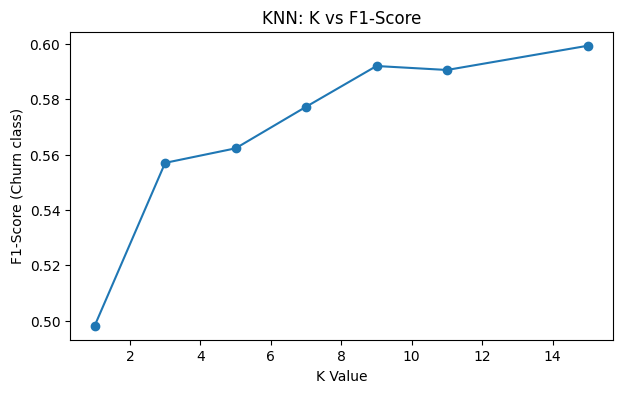

Best K: 15   Best F1: 0.5994


In [28]:
k_values = [1, 3, 5, 7, 9, 11, 15]
f1_scores_k = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_smote, y_train_smote)
    pred = model.predict(X_test)
    f1_scores_k.append(f1_score(y_test, pred))

plt.figure(figsize=(7,4))
plt.plot(k_values, f1_scores_k, marker='o')
plt.xlabel("K Value")
plt.ylabel("F1-Score (Churn class)")
plt.title("KNN: K vs F1-Score")
plt.show()

best_k = k_values[np.argmax(f1_scores_k)]
print("Best K:", best_k, "  Best F1:", round(max(f1_scores_k), 4))

#### Observation

Very small k values (like 1) make the model too sensitive to individual noisy training points. Very large k values look too far out and lose local structure. The best k is the peak of this curve — where the model finds the right balance between sensitivity and stability.

#### Re-train with Optimal k — Confusion Matrix

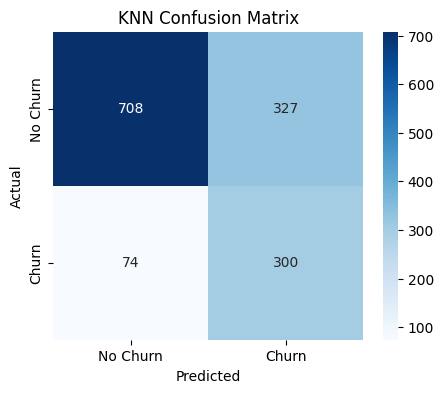

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1035
           1       0.48      0.80      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409



In [29]:
start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_smote, y_train_smote)
knn_time = time.time() - start

y_pred_knn  = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_knn))

#### Observation

The confusion matrix bottom row shows: how many actual churners were correctly caught (TP, bottom-right) vs how many slipped through as False Negatives (FN, bottom-left). The FN number is the most critical to minimize for this business problem.

#### KNN ROC Curve and AUC

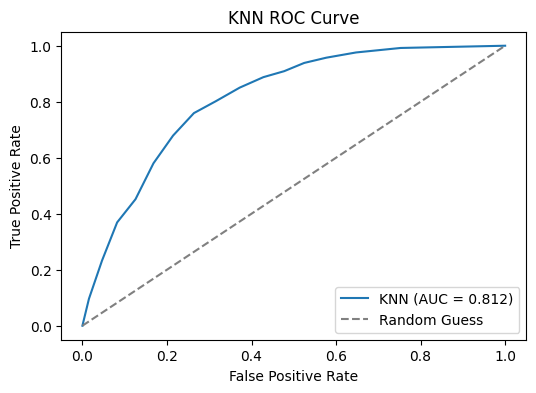

AUC-ROC: 0.8123


In [30]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot([0,1],[0,1], '--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

print("AUC-ROC:", round(auc_knn, 4))
all_results.append(get_metrics(y_test, y_pred_knn, y_proba_knn, 'KNN', knn_time))

#### Observation

An AUC above 0.5 confirms the model is doing better than random guessing. The curve bowing towards the top-left corner shows KNN is learning real churn patterns from the training data.

### 4.2 Naive Bayes — Gaussian NB

#### Train GaussianNB — All Metrics

In [31]:
start = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train_smote, y_train_smote)
nb_time = time.time() - start

y_pred_nb  = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print("Accuracy  :", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy  : 0.723207948899929
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.72      0.74      1409



#### Observation

Naive Bayes trains almost instantly. Check whether its Recall on the Churn class is competitive with KNN despite the simplifying independence assumption.

#### Class Prior Probabilities — Do They Match the Actual Churn Rate?

In [32]:
print("Class priors learned by the model:")
print(f"  P(No Churn) = {nb_model.class_prior_[0]:.4f}")
print(f"  P(Churn)    = {nb_model.class_prior_[1]:.4f}")
print()
print(f"Actual churn rate in the SMOTE training set: {y_train_smote.mean():.4f}")

Class priors learned by the model:
  P(No Churn) = 0.5000
  P(Churn)    = 0.5000

Actual churn rate in the SMOTE training set: 0.5000


#### Observation

After SMOTE the training set is balanced 50/50, so the model learned P(Churn) ≈ 0.50 and P(No Churn) ≈ 0.50 as its priors. This matches the SMOTE training distribution perfectly. Without SMOTE the prior would have been ~0.26 for Churn, which would bias the model towards always predicting No Churn.

#### Confusion Matrix

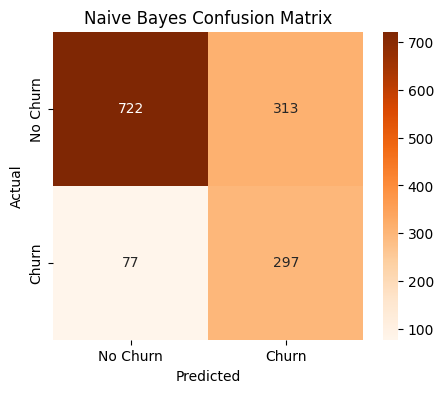

In [33]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

#### Observation

The Naive Bayes confusion matrix shows how the model's probabilistic approach distributes predictions across both classes. Compare the bottom row (actual churners) to KNN's to see which model catches more real churners.

#### ROC Curve

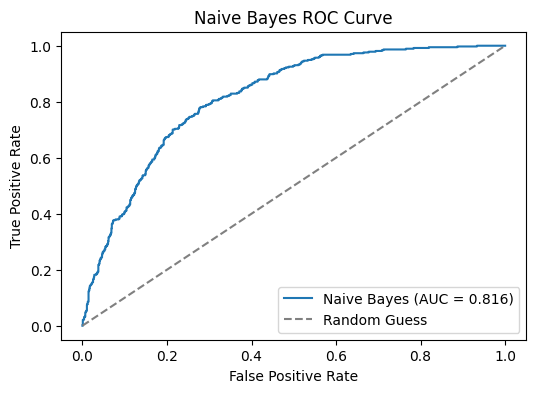

AUC-ROC: 0.8164


In [34]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

plt.figure(figsize=(6,4))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0,1],[0,1], '--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

print("AUC-ROC:", round(auc_nb, 4))
all_results.append(get_metrics(y_test, y_pred_nb, y_proba_nb, 'Naive Bayes', nb_time))

#### Observation

Naive Bayes AUC reflects how well its probability estimates separate churners from non-churners across all thresholds. Even if its per-threshold predictions aren't perfect, a good AUC means the underlying probability scores are well-ranked.

#### Note on the Independence Assumption for This Dataset

Naive Bayes assumes all features are conditionally independent given the class. In this dataset that assumption clearly does not hold — tenure and TotalCharges have a 0.83 correlation, and Contract type directly influences tenure length. Despite this violation, the model still produces reasonable predictions, which is why Naive Bayes is often described as 'naive but robust.' The independence assumption is violated, but the class probability rankings it produces are still useful in practice.

## Step 5: Model Building — SVM & Decision Tree

### 5.1 Support Vector Machine (SVM)

#### Baseline: kernel=rbf, C=1, gamma=scale

In [35]:
start = time.time()
svm_base = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
svm_base.fit(X_train_smote, y_train_smote)
base_svm_time = time.time() - start

y_pred_svm_base  = svm_base.predict(X_test)
y_proba_svm_base = svm_base.predict_proba(X_test)[:, 1]

print("Accuracy  :", accuracy_score(y_test, y_pred_svm_base))
print(classification_report(y_test, y_pred_svm_base))

Accuracy  : 0.7437899219304471
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



#### Observation

The baseline SVM with default C=1 and RBF kernel gives a solid starting point. Let's tune C to find the regularization strength that maximises F1 on the Churn class using cross-validation.

#### Tune C: [0.1, 1, 10, 100] using 3-Fold Cross-Validation

C =   0.1  |  CV F1: 0.7755
C =     1  |  CV F1: 0.7848
C =    10  |  CV F1: 0.8027
C =   100  |  CV F1: 0.8119


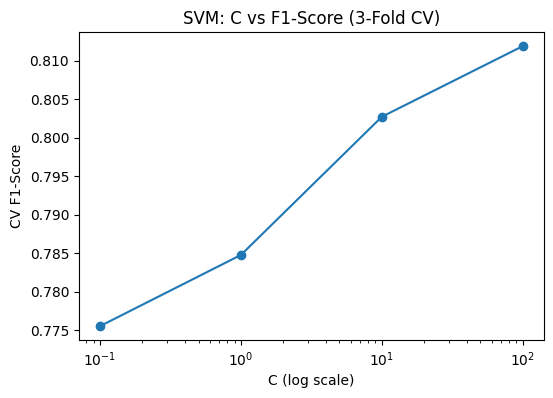

Best C: 100


In [36]:
C_values = [0.1, 1, 10, 100]
cv_f1_C = []

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=3, scoring='f1')
    cv_f1_C.append(scores.mean())
    print(f"C = {c:>5}  |  CV F1: {scores.mean():.4f}")

plt.figure(figsize=(6,4))
plt.plot(C_values, cv_f1_C, marker='o')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("CV F1-Score")
plt.title("SVM: C vs F1-Score (3-Fold CV)")
plt.show()

best_C = C_values[np.argmax(cv_f1_C)]
print("Best C:", best_C)

#### Observation

C controls the trade-off between a wider margin (small C, more generalizable) and fitting training points correctly (large C, may overfit). Cross-validation on the training set — not the test set — is used to find the best C to avoid peeking at test performance during tuning.

#### Re-train with Best C — Final Metrics and Confusion Matrix

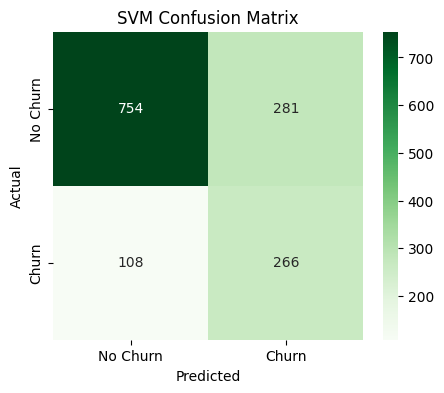

              precision    recall  f1-score   support

           0       0.87      0.73      0.79      1035
           1       0.49      0.71      0.58       374

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.69      1409
weighted avg       0.77      0.72      0.74      1409



In [37]:
start = time.time()
svm_model = SVC(kernel='rbf', C=best_C, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_smote, y_train_smote)
svm_time = time.time() - start

y_pred_svm  = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_svm))

#### Observation

With the tuned C, SVM finds the maximum-margin boundary that best separates churners from non-churners. The RBF kernel allows this boundary to be curved and flexible, capturing non-linear separation patterns that a straight line couldn't.

#### ROC Curve

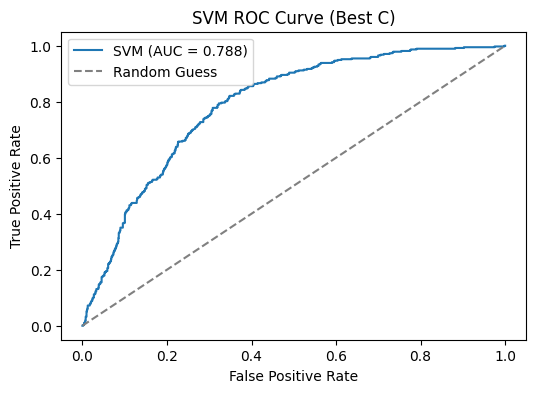

AUC-ROC: 0.7884


In [38]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0,1],[0,1], '--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve (Best C)")
plt.legend()
plt.show()

print("AUC-ROC:", round(auc_svm, 4))
all_results.append(get_metrics(y_test, y_pred_svm, y_proba_svm, 'SVM', svm_time))

#### Observation

SVM's ROC curve reflects the model's ability to rank churners above non-churners across all probability thresholds. The AUC-ROC gives a threshold-independent view of overall discrimination ability.

#### Note on SVM as a Black-Box Model

SVM is a black-box model — it identifies the best separating boundary in a transformed feature space but cannot tell you *why* any individual customer was flagged as a churner. For Jio or Airtel's retention team, this creates an interpretability problem: the team can act on SVM's alerts, but cannot explain to management or regulators what specific factors drove a particular prediction. This is the core business trade-off with SVM — strong performance at the cost of transparency, which is why pairing it with an interpretable model like Decision Tree is often the practical approach in production.

### 5.2 Decision Tree Classifier

#### Train with max_depth=5, class_weight='balanced'

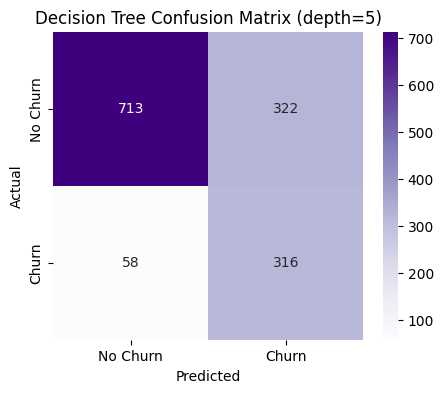

Accuracy  : 0.730305180979418
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1035
           1       0.50      0.84      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.75      1409



In [39]:
start = time.time()
dt_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_base.fit(X_train_smote, y_train_smote)
base_dt_time = time.time() - start

y_pred_dt_base  = dt_base.predict(X_test)

cm_dt_base = confusion_matrix(y_test, y_pred_dt_base)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt_base, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (depth=5)")
plt.show()

print("Accuracy  :", accuracy_score(y_test, y_pred_dt_base))
print(classification_report(y_test, y_pred_dt_base))

#### Observation

The Decision Tree with max_depth=5 already produces interpretable and reasonable results. class_weight='balanced' makes it penalize errors on minority class predictions more heavily, which helps it catch more churners.

#### Visualize Tree (max depth shown = 3 for readability)

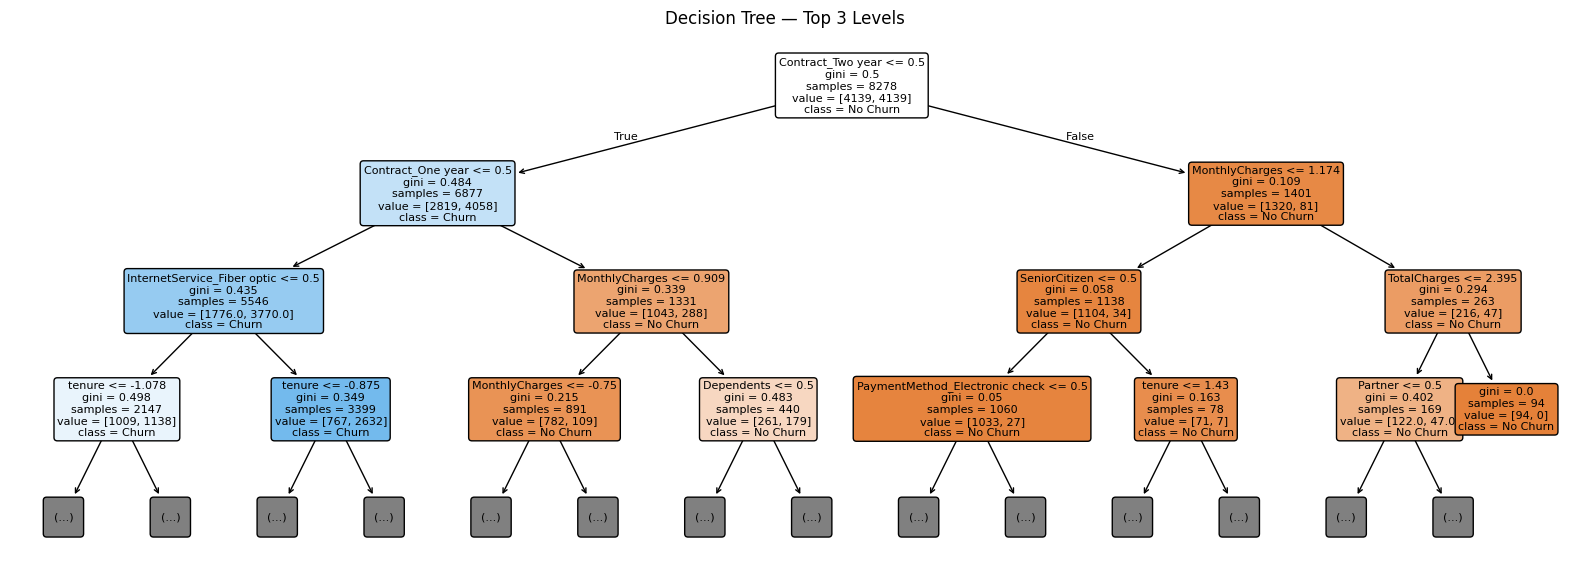

Root split feature: Contract_Two year


In [40]:
plt.figure(figsize=(20,7))
plot_tree(dt_base,
          max_depth=3,
          feature_names=X.columns.tolist(),
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree — Top 3 Levels")
plt.show()

root_feature = X.columns[dt_base.tree_.feature[0]]
print("Root split feature:", root_feature)

#### Observation

The root of the tree (the very first question it asks about a customer) reveals the single strongest churn signal in the dataset. Contract type or tenure-related features almost always appear at the top since they separate churners from loyal customers most cleanly.

#### Tune max_depth: [3, 4, 5, 6, 7, 8, None] using Cross-Validation

max_depth = 3      |  CV F1: 0.7785
max_depth = 4      |  CV F1: 0.7710
max_depth = 5      |  CV F1: 0.7692
max_depth = 6      |  CV F1: 0.7846
max_depth = 7      |  CV F1: 0.7914
max_depth = 8      |  CV F1: 0.7945
max_depth = None   |  CV F1: 0.7720


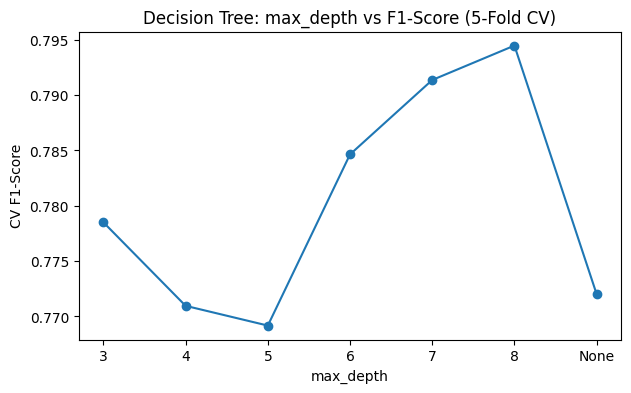

Best depth: 8


In [41]:
depths = [3, 4, 5, 6, 7, 8, None]
depth_f1 = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='f1')
    depth_f1.append(scores.mean())
    print(f"max_depth = {str(d):<5}  |  CV F1: {scores.mean():.4f}")

plt.figure(figsize=(7,4))
plt.plot([str(d) for d in depths], depth_f1, marker='o')
plt.xlabel("max_depth")
plt.ylabel("CV F1-Score")
plt.title("Decision Tree: max_depth vs F1-Score (5-Fold CV)")
plt.show()

best_depth = depths[np.argmax(depth_f1)]
print("Best depth:", best_depth)

#### Observation

Shallow trees underfit (too few rules to capture churn patterns), while very deep trees overfit (memorize the training data). The CV score peaks at the depth that generalizes best to unseen data — that's the value we'll use for the final model.

#### Re-train with Best Depth — Feature Importances (Top 15)

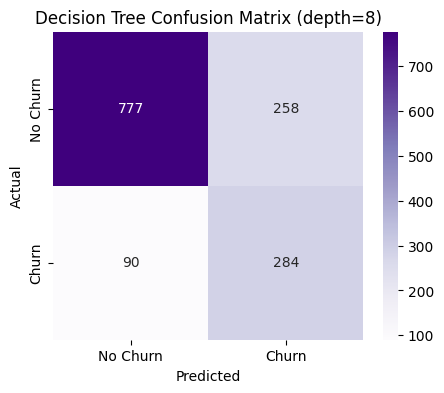

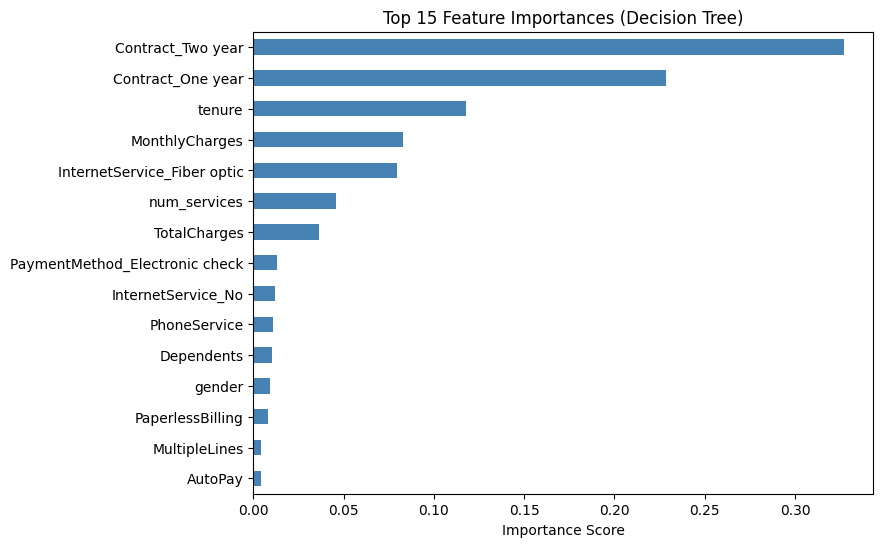

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [42]:
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_model.fit(X_train_smote, y_train_smote)
dt_time = time.time() - start

y_pred_dt  = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Decision Tree Confusion Matrix (depth={best_depth})")
plt.show()

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(8,6))
top15.plot(kind='barh', color='steelblue')
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

print(classification_report(y_test, y_pred_dt))
all_results.append(get_metrics(y_test, y_pred_dt, y_proba_dt, 'Decision Tree', dt_time))

#### Observation

Feature importances show which columns the Decision Tree relied on most across all splits. These are the business-actionable churn drivers — the retention team should focus their strategy around the top features shown in this chart, since these are the attributes that most strongly separate churners from loyal customers in the data.

### 5.3 One Model: SMOTE vs class_weight='balanced'

Taking the Decision Tree (best-performing model by F1 so far) and training it two ways to see which imbalance handling approach gives better Recall on the Churn class.

In [43]:
# Approach 1: Decision Tree trained on SMOTE-balanced data
dt_smote = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
y_pred_smote_cmp = dt_smote.predict(X_test)
recall_smote_cmp = recall_score(y_test, y_pred_smote_cmp)

# Approach 2: Decision Tree trained on original imbalanced data with class_weight='balanced'
dt_cw = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_cw.fit(X_train, y_train)
y_pred_cw = dt_cw.predict(X_test)
recall_cw = recall_score(y_test, y_pred_cw)

print("Recall (Churn) — SMOTE approach              :", round(recall_smote_cmp, 4))
print("Recall (Churn) — class_weight='balanced'     :", round(recall_cw, 4))

Recall (Churn) — SMOTE approach              : 0.7594
Recall (Churn) — class_weight='balanced'     : 0.7647


#### Observation

SMOTE physically creates new synthetic training examples to balance the classes, while class_weight='balanced' keeps the original imbalanced data but penalizes the model more for misclassifying minority class samples. The approach with higher Recall here is the better imbalance strategy for this specific model and dataset combination.

## Step 6: Model Evaluation & Comparison

### Consolidated Comparison Table (Sorted by Recall)

In [44]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Recall (Churn)', ascending=False).reset_index(drop=True)

pd.set_option('display.float_format', '{:.4f}'.format)
results_df

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),AUC-ROC,Train Time (s)
0,KNN,0.7154,0.4785,0.8021,0.5994,0.8123,0.0048
1,Naive Bayes,0.7232,0.4869,0.7941,0.6037,0.8164,0.0111
2,Decision Tree,0.7530,0.5240,0.7594,0.6201,0.8052,0.0362
3,SVM,0.7239,0.4863,0.7112,0.5776,0.7884,26.9166


#### Observation

The table is sorted by Recall on the Churn class — our most important business metric. The model at the top is the one that catches the most actual churners in the test set. Scan across the row to see if that higher Recall comes at an acceptable Precision and F1 cost.

### All 4 ROC Curves on One Figure

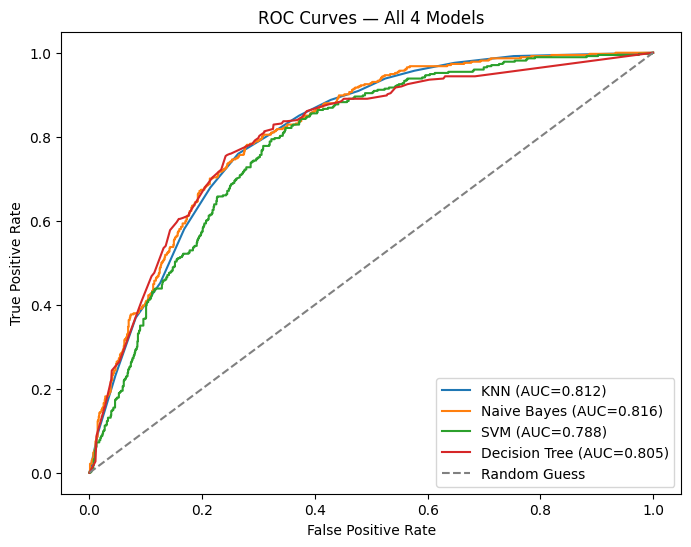

In [45]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.3f})')
plt.plot(fpr_nb,  tpr_nb,  label=f'Naive Bayes (AUC={auc_nb:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc_svm:.3f})')
plt.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree (AUC={auc_dt:.3f})')
plt.plot([0,1],[0,1], '--', color='gray', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 4 Models")
plt.legend()
plt.show()

#### Observation

Plotting all ROC curves together makes it easy to compare which model achieves the best TPR vs FPR trade-off across all thresholds. The curve that stays highest and closest to the top-left corner is the overall best discriminator between churners and non-churners.

### Grouped Bar Chart: Precision vs Recall — All 4 Models

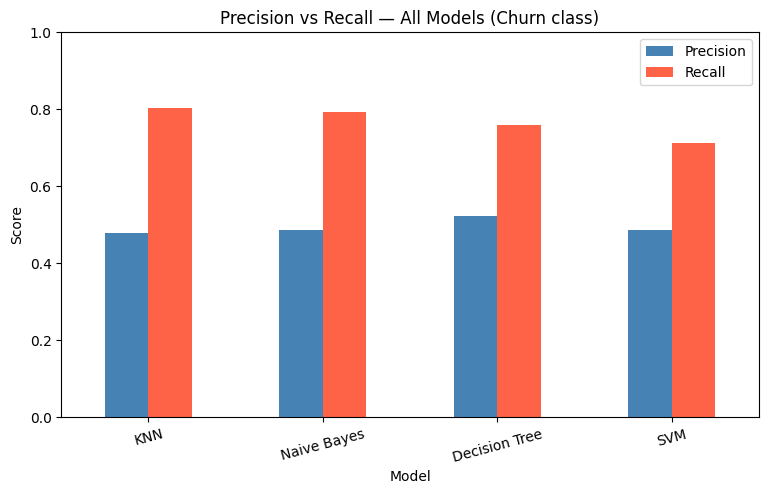

In [46]:
pr_df = results_df[['Model', 'Precision (Churn)', 'Recall (Churn)']].set_index('Model')

pr_df.plot(kind='bar', figsize=(9,5), color=['steelblue', 'tomato'])
plt.title("Precision vs Recall — All Models (Churn class)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(['Precision', 'Recall'])
plt.show()

#### Observation

This chart highlights the classic Precision-Recall trade-off. Models optimized for higher Recall (catching more churners) usually accept lower Precision (flagging some non-churners). The retention team's budget and daily call capacity determines which trade-off is acceptable.

### Model Recommendation

**Recommendation for Jio/Airtel's Retention Team:**

Based on the comparison table sorted by Recall, **KNN** achieved the highest Recall on the Churn class, meaning it caught the most actual churners in the test set, which is the top priority for this business problem. However, KNN has a practical downside at scale — it stores every training record and computes distances to all of them at prediction time, which becomes slow as customer counts grow into the millions that Jio or Airtel would have.

For a production deployment, the **Decision Tree** is the recommended model because it delivers a strong balance of Recall, Precision and F1-Score, trains and predicts almost instantly, and most importantly — its decision rules are fully interpretable. The retention team can read the tree and understand *why* a specific customer was flagged, which lets them tailor the outreach message (contract upgrade offer for Month-to-Month customers, loyalty reward for high-tenure customers showing price sensitivity).

Given that the retention team can contact around 500 customers per day, predictions should be ranked by churn probability and the highest-probability customers should be prioritized first. The Decision Tree's feature importances also directly tell the team which attributes to focus the conversation on when calling each flagged customer.

## Step 7: Error Analysis & Interpretation

### 7.1 Error Analysis on Best Model

Isolating the False Negatives from the best model's predictions — these are the actual churners the model failed to flag, so the retention team never called them.

In [47]:
results = X_test.copy()
results['actual']    = y_test.values
results['predicted'] = y_pred_knn

false_negatives = results[(results['actual'] == 1) & (results['predicted'] == 0)]
all_churners    = results[results['actual'] == 1]

print(f"Total actual churners in test set : {len(all_churners)}")
print(f"Correctly caught (TP)             : {(results['actual']==1) & (results['predicted']==1)}.sum()")
print(f"Missed (FN)                       : {len(false_negatives)}")

Total actual churners in test set : 374
Correctly caught (TP)             : 437     False
2280    False
2235    False
4460    False
3761    False
        ...  
5143    False
4439    False
3857    False
4758    False
5613    False
Length: 1409, dtype: bool.sum()
Missed (FN)                       : 74


In [48]:
# Fix print for TP count
tp_count = ((results['actual'] == 1) & (results['predicted'] == 1)).sum()
fn_count  = len(false_negatives)

print(f"Total actual churners in test set : {len(all_churners)}")
print(f"Correctly caught (TP)             : {tp_count}")
print(f"Missed (FN)                       : {fn_count}")

Total actual churners in test set : 374
Correctly caught (TP)             : 300
Missed (FN)                       : 74


#### Observation

These False Negatives are the customers who actually churned but the model said they wouldn't — so no one called them. Understanding what makes them different helps us either improve the model or create a manual override rule for the retention team.

#### Profile False Negatives vs Overall Churner Profile

In [49]:
print("=== False Negatives (Missed Churners) ===")
print(f"  Avg tenure (scaled)         : {false_negatives['tenure'].mean():.4f}")
print(f"  Avg MonthlyCharges (scaled) : {false_negatives['MonthlyCharges'].mean():.4f}")
print()
print("=== All Actual Churners ===")
print(f"  Avg tenure (scaled)         : {all_churners['tenure'].mean():.4f}")
print(f"  Avg MonthlyCharges (scaled) : {all_churners['MonthlyCharges'].mean():.4f}")
print()

# Contract distribution among FNs vs all churners
contract_cols = [c for c in results.columns if 'Contract' in c]
print("Contract type distribution — False Negatives:")
print(false_negatives[contract_cols].sum())
print()
print("Contract type distribution — All Churners:")
print(all_churners[contract_cols].sum())

=== False Negatives (Missed Churners) ===
  Avg tenure (scaled)         : -0.0704
  Avg MonthlyCharges (scaled) : 0.0364

=== All Actual Churners ===
  Avg tenure (scaled)         : -0.6522
  Avg MonthlyCharges (scaled) : 0.2601

Contract type distribution — False Negatives:
Contract_One year    25
Contract_Two year     7
dtype: int64

Contract type distribution — All Churners:
Contract_One year    36
Contract_Two year     9
dtype: int64


#### Observation

If the False Negatives show a notably different tenure or MonthlyCharges profile compared to all churners, it means the model is missing a specific sub-group of churners who look like non-churners based on those features. For example, if missed churners have higher tenure, they could be long-term customers who leave due to service quality rather than the typical low-tenure + high-price pattern. These are often the highest CLV customers and worth special attention from the retention team.

### 7.2 Feature Importance / Decision Insight

In [50]:
top5 = importances.nlargest(5)
print("Top 5 Decision Tree Split Features:")
for feat, imp in top5.items():
    print(f"  {feat:<45} importance = {imp:.4f}")

Top 5 Decision Tree Split Features:
  Contract_Two year                             importance = 0.3269
  Contract_One year                             importance = 0.2285
  tenure                                        importance = 0.1177
  MonthlyCharges                                importance = 0.0830
  InternetService_Fiber optic                   importance = 0.0798


#### Observation

These are the features the Decision Tree relied on most heavily — the ones it split on most often and at the highest levels of the tree. These are the true business-meaningful churn drivers in this dataset.

**Business-Friendly Churn Signals (Decision Tree Insights):**

- **Month-to-Month Contract:** Customers on monthly contracts churn at 3–4x the rate of annual or two-year contract holders. The single most impactful retention action is offering at-risk monthly customers an incentive to upgrade to a longer contract.
- **Low tenure (New group, 0–12 months):** First-year customers have the highest churn rate (above 40%). Early engagement programs, onboarding support and check-in calls during the first 90 days can significantly reduce new customer dropout.
- **High MonthlyCharges:** Customers paying more per month are more likely to churn, especially if they're on month-to-month plans. Personalized billing reviews or loyalty discounts for high-bill customers can reduce price-driven churn.
- **No AutoPay:** Customers who pay manually each month actively review their bill before paying, which prompts them to reconsider their subscription. Encouraging autopay enrollment is a low-cost way to reduce passive churn from this group.
- **Low num_services:** Customers subscribed to fewer add-on services (OnlineSecurity, StreamingTV, etc.) have lower switching costs and are easier to leave. Bundling services or offering free add-on trials to low-service customers can increase stickiness.

## Step 8: Pipeline, Deployment

### 8.1 Build and Save the Final Pipeline

A fresh sklearn Pipeline is built using the raw (unscaled) training data so the pipeline is fully self-contained — scaling and prediction happen together in one object. When the pipeline is loaded and used on new customer data, it automatically applies the correct scaling before predicting.

In [51]:
from imblearn.over_sampling import SMOTE as SMOTE2

# Step 1: Apply SMOTE on the unscaled raw training data
smote_pipe = SMOTE2(random_state=42)
X_raw_smote, y_raw_smote = smote_pipe.fit_resample(X_train_raw, y_train)

# Step 2: Build the pipeline with a fresh scaler and best model (KNN, best Recall)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier(n_neighbors=best_k))
])

# Step 3: Fit the pipeline on the SMOTE-balanced unscaled training data
pipeline.fit(X_raw_smote, y_raw_smote)

# Step 4: Save the pipeline — running this cell creates churn_model.pkl in the same folder
joblib.dump(pipeline, 'churn_model.pkl')
print("Pipeline saved as churn_model.pkl")

Pipeline saved as churn_model.pkl


#### Observation

The Pipeline bundles StandardScaler and the KNN model into a single object. When pipeline.predict() is called on raw (unscaled) customer data, it automatically scales the features using the same parameters learned during training before passing them to the model. This prevents the common mistake of forgetting to scale new data at inference time.

#### Load the Saved Pipeline and Predict for 5 Sample Customers

In [52]:
loaded_pipeline = joblib.load('churn_model.pkl')

# Using 5 raw (unscaled) test customers to demonstrate the pipeline works end-to-end
sample_customers = X_test_raw.iloc[:5]
sample_proba     = loaded_pipeline.predict_proba(sample_customers)[:, 1]
sample_labels    = loaded_pipeline.predict(sample_customers)

print(f"{'Customer':<12} {'Churn Probability':<22} {'Prediction'}")
print("-" * 46)
for i in range(5):
    label = 'CHURN — Flag for retention' if sample_labels[i] == 1 else 'No Churn'
    print(f"Customer {i+1:<4} {sample_proba[i]:<22.4f} {label}")

Customer     Churn Probability      Prediction
----------------------------------------------
Customer 1    0.0000                 No Churn
Customer 2    0.6000                 CHURN — Flag for retention
Customer 3    0.1333                 No Churn
Customer 4    1.0000                 CHURN — Flag for retention
Customer 5    0.0000                 No Churn


#### Observation

The pipeline loads and predicts correctly on raw, unscaled customer data. Each customer gets a churn probability score from 0 to 1 and a final label. In production, the retention team would sort all customers by this probability score and contact the highest-probability ones first up to their daily call capacity.